# TP3: elliptic 1D equation with FEM

In [ ]:
#Install package
import sys
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install scikit-fem

In [1]:
# import packages

import skfem  # for Finite Element Method
import numpy as np
import matplotlib.pyplot as plt
import random

============================================================
 
### POD-Galerkin with FEM
## 1) First exercise: Reproduce course example 

 Elliptic diffusion problem (1D) with scikit-fem:
 
   $ -\frac{d}{dx} ( A(\mu) \frac{du}{dx} ) = f(x)  \ \mathrm{ on }\ (0, 0.5)$ 
   
$    u(0) = u(0.5) = 0  (Dirichlet)$

    -------------------
    
    FEM:
 
 Find $u_h = \sum_{i=1}^{\mathcal{N}} u_i w_i$ such that :

   $a(u_h,v_h;\mu)=l(v_h) \forall v_h \in V_h$

 with Dirichlet boundary $u=0$ on $\partial \Omega$.

 Here $\Omega=[0,0.5] $. We use a uniform mesh, with $Ne + 1$ degrees of freedom.
 
$A(\mu)=0.1 + \mu$

$f(x) = sin(2\pi  x) $

--------
Solve the problem for $\mu_1 = 0.5$ and $mu_2 = 1.5$

In [ ]:
"""
Elliptic diffusion problem (1D) with scikit-fem:
    -d/dx ( a(mu) * du/dx ) = f(x)   on (0, 1)
    u(0) = u(1) = 0  (Dirichlet)

We solve it for two parameters mu1, mu2 (via a(mu)),
and also plot an intermediate solution between them.
"""
from skfem import MeshLine, Basis, asm, enforce,solve
from skfem.element import ElementLineP1
from skfem.helpers import dot, grad
from skfem.assembly import BilinearForm, LinearForm

# -----------------------
# Problem setup
# -----------------------
Ne = 100 # number of mesh points 

m = MeshLine(np.linspace(0.0, 0.5, Ne + 1))
basis = Basis(m, ElementLineP1())

# Dirichlet boundary DOFs 
D = basis.get_dofs().all()  # all dofs

# Parameter-dependent diffusion coefficient
def A_mu(mu):
    return ...

# Sinusoidal source term : compute int f*v
@LinearForm
def rhs(v, w):
    x = w.x[0]
    f = ...  # sinusoidal source
    return ...


@BilinearForm
def diffusion(u, v, w):
    return ...


def FEMassembling(m):
    """
    m= mesh
    return A,b (no parameter dependance)
    """
    basis = Basis(m, ElementLineP1())
    
    A = asm(diffusion, basis) #assembling stiffness
    b = asm(rhs, basis)
    return A,b


def FEMsolve(A,b,m,mu):
    # solve Au=b
    # Apply homogeneous Dirichlet at x=0,0.5
    
    ... = enforce(...,..., D=m.boundary_nodes()) #enforce boundary conditions on A and b
    u = ...
    return u


# -----------------------------------
# Solve for two mus + an intermediate
# -----------------------------------
mu1 = ...
mu2 = ...
theta = ...  # intermediate parameter weight 
mu_mid = ...

A,b=...
u1 = ...
u2 = ...
umid = ...

#linear combination in solution space:
theta2 = ...
u_lin = ...

x_fine = basis.doflocs[0] 
plt.figure(figsize=(8, 4.5))
plt.plot(x_fine, u1, lw=2, label=fr"$u(\mu_1)$, $\mu_1={mu1}$, $A={A_mu(mu1):.3g}$")
plt.plot(x_fine, u2, lw=2, label=fr"$u(\mu_2)$, $\mu_2={mu2}$, $A={A_mu(mu2):.3g}$")
plt.plot(x_fine, umid, lw=2, label=fr"$u(\mu_{{mid}})$, $\mu_{{mid}}={mu_mid}$, $A={A_mu(mu_mid):.3g}$")
plt.plot(x_fine, u_lin, "--", lw=2, label=fr"linear blend $\alpha_1 u(\mu_1)+\alpha_2\ u(\mu_2)$")


plt.xlabel("x")
plt.ylabel("u(x)")
plt.title(r"Elliptic diffusion: $-(A(\mu)u')' = \sin(2\pi x)$,  $u(0)=u(0.5)=0$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



In [6]:
""" POD """
### USE AND ADAPT TP1 FUNCTION...

def Construct_RB(NumberOfSnapshots=100,NumberOfModes=20,m=m):
    """
    NumberOfSnapshots= Training set
    NumberOfModes= N 
    m=mesh
    """
    print("number of modes: ",NumberOfModes)
    basis =...
    A,b = ...
    
    Snapshots=[]
    for i in range(NumberOfSnapshots):
        mu = ... #random coefficient in [1,10] 
        U = ...
        
        Snapshots.append(U)
        
    print("last parameter:",mu)

    ## SVD ##

    #(u,v)_L2=v^T M u
    @BilinearForm
    def massVelocity(u, v, _):
        return u * v
    
    L2=massVelocity.assemble(basis)

    # We first compute the correlation matrix C_ij = (u_i,u_j)
    CorrelationMatrix = np.zeros((NumberOfSnapshots, NumberOfSnapshots))
    ...
    
    # Then, we compute the eigenvalues/eigenvectors of C 
    # sort the eigenvalues
    # retrieve N=NumberOfModes first eigenvalues
    
    print("Relativ Information Content (must be close to 0): ",RIC)
    
    ReducedBasis = ...

    return ReducedBasis

number of modes:  20
last parameter: 6.143665788168235
eigenvalues:  [8.98119945e-04 3.14744663e-19 1.86645528e-19 1.60949973e-19
 1.47391858e-19 1.39085760e-19 1.23763284e-19 1.09913265e-19
 9.82897092e-20 9.02160650e-20 8.61172372e-20 7.35151495e-20
 6.22059607e-20 5.34464736e-20 4.79110054e-20 4.45199243e-20
 4.14772357e-20 3.27361686e-20 2.92939093e-20 2.59839285e-20]
Relativ Information Content (must be close to 0):  -2.220446049250313e-15


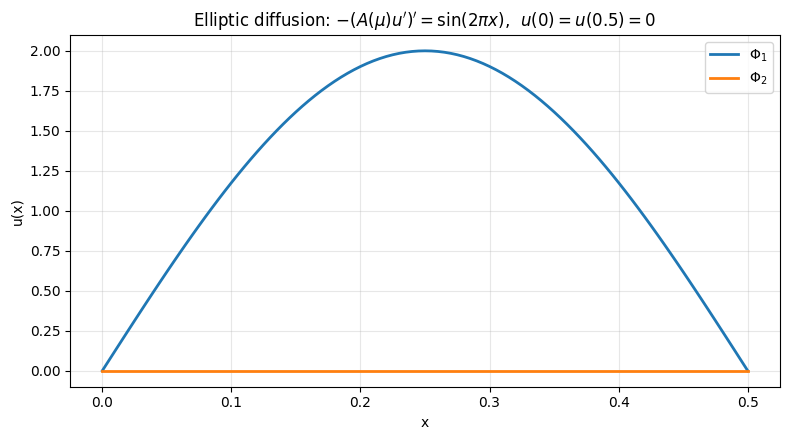

In [7]:
## test POD

Ne = 100
m = MeshLine(np.linspace(0.0, 0.5, Ne + 1))
basis = ...
ReducedBasis=...     
x_fine = basis.doflocs[0] 

plt.figure(figsize=(8, 4.5))
plt.plot(x_fine, ReducedBasis[:,0], lw=2, label=fr"$\Phi_1$")
plt.plot(x_fine, ReducedBasis[:,1], lw=2, label=fr"$\Phi_2$")


plt.xlabel("x")
plt.ylabel("u(x)")
plt.title(r"Elliptic diffusion: $-(A(\mu)u')' = \sin(2\pi x)$,  $u(0)=u(0.5)=0$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
# POD-Galerkin

A, b = FEMassembling(m)
def solve_fem_rom(A,b,mu, Phi,m):
    # assemble full system
   
    ...
    return a, u_rom #( or return only u_rom)


In [ ]:
mu = mu_mid
Ne = 100
m = MeshLine(np.linspace(0.0, 0.5, Ne + 1))
basis = Basis(m, ElementLineP1())
A,b=FEMassembling(m)
a,u_proj=solve_fem_rom(A,b,mu, Phi,m)
x_fine = basis.doflocs[0] 

plt.plot(x_fine,u_proj, lw=2, label="$urom_{mid}$")
plt.plot(x_fine, umid, lw=2, label=fr"$u(\mu_{{mid}})$, $\mu_{{mid}}={mu_mid}$, $A={A_mu(mu_mid):.3g}$")
plt.plot(x_fine, u_lin, "--", lw=2, label=fr"linear blend $\alpha_1\ u(\mu_1)+\alpha_2\ u(\mu_2)$")


plt.xlabel("x")
plt.ylabel("u(x)")
plt.title(r"Elliptic diffusion: $-(A(\mu)u')' = \sin(2\pi x)$,  $u(0)=u(0.5)=0$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#### Convergence

mu = 0.6
@BilinearForm

def massVelocity(u, v, _):
    return u*v

err_true=[]
err_rom=[]
# choose grid sizes to test
Ns = [...] # adapt as you want
for n in Ns:
    print("n",n)
    m = ...
    basis = ...
    L2=massVelocity.assemble(basis)
    xc = basis.doflocs[0] 
    
    A, b = ...
    U = ...
    Phi=...

    _,Uproj=...

    points_new = xc
    u_exact=... #compute true solution
   
    ## print error
    true_error = np.abs(u_exact - U)
    l2_true_error=np.sqrt(true_error@L2.dot(true_error))
    print(l2_true_error)
    rom_error = np.abs(u_exact - Uproj)
    l2_rom_error=np.sqrt(rom_error@L2.dot(rom_error))


   # L2 errors (cellwise)
    err_true.append(l2_true_error)
    err_rom.append(l2_rom_error)

# ---------------------------
# Plot log-log convergence
# ---------------------------
hs = np.array(Ns)
err_true = np.array(err_true)
err_rom = np.array(err_rom)

plt.figure()
plt.loglog(hs, err_true, "o-", label=r"$\|u_{ref}-u\|_{L^2}$")
plt.loglog(hs, 1/(hs**...), "-", label=r"$h^2$")
plt.loglog(hs, err_rom, "s-", label=r"$\|u_{ref}-u_N\|_{L^2}$")
plt.gca().invert_xaxis()  # optional: smaller h to the right
plt.xlabel(r"$h$")
plt.ylabel(r"$L^2$ error")
plt.grid(True, which="both")
plt.legend()
plt.show()


##### 